# NBA win/loss model

XGB Classifier optimised with time-series CV within Bayes Optimisation. Model is calibrated using Platt scaling and threshold is optimised using precision-recall curve. Data is on a match level granularity with home team stats and visitor team stats. Team level stats include rolled features such as avg_pts and avg_pts_last5, as well as season averages from the previous season. Majority of the team stats are diffed as XGB is better of viewing differentials than comparisons. 

Current best metric: \
 Accuracy: 0.6499 \
 Log Loss: 0.7517 \
 Brier Score: 0.2482 

Which is honestly not good as accuracy is the only metric that performs better than baseline (baseline accuracy: 0.5435). Log loss is higher than baseline roughly by .05 and Brier score is the same as baseline.

I believe the main issue is the features as the season averages is from the previous season and not rolling. So the average pts scored from 2021/2022 is not a strong representation of the teams average pts scored in 2022/2023 season for example. Things like player trades, coaching staff changes, etc are essentially ignored. The only reason I use season averages from previous season is because I can't find reliable data of team stats prior to matches that date back to the 2021 season without needing to pay. 

I also need historical odds data so I can determine the value of the bet and backtest my model. The math is easy, I just don't have the data. 

Next steps:
- SHAP analysis to determine strong features and redudant features
- Backtest on 2024/2025 season 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Get data 

In [3]:
matchData = pd.read_csv("data/matchData.csv")
matchData.head()

,Date,Visitor,visitorPTS,Home,homePTS
0,Tue Oct 19 2021,Brooklyn Nets,104,Milwaukee Bucks,127
1,Tue Oct 19 2021,Golden State Warriors,121,Los Angeles Lakers,114
2,Wed Oct 20 2021,Indiana Pacers,122,Charlotte Hornets,123
3,Wed Oct 20 2021,Chicago Bulls,94,Detroit Pistons,88
4,Wed Oct 20 2021,Boston Celtics,134,New York Knicks,138


In [4]:
matchData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5729 entries, 0 to 5728
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        5729 non-null   object
 1   Visitor     5729 non-null   object
 2   visitorPTS  5729 non-null   int64 
 3   Home        5729 non-null   object
 4   homePTS     5729 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 223.9+ KB


In [5]:
teamData2020 = pd.read_csv("data/2020PerGameData.csv")
advData2020 = pd.read_csv("data/2020AdvData.csv")
teamData2021 = pd.read_csv("data/2021PerGameData.csv")
advData2021 = pd.read_csv("data/2021AdvData.csv")
teamData2022 = pd.read_csv("data/2022PerGameData.csv")
advData2022 = pd.read_csv("data/2022AdvData.csv")
teamData2023 = pd.read_csv("data/2023PerGameData.csv")
advData2023 = pd.read_csv("data/2023AdvData.csv")
teamData2024 = pd.read_csv("data/2024PerGameData.csv")
advData2024 = pd.read_csv("data/2024AdvData.csv")

In [6]:
teamData2020.head()

,Team,G,MP,FG,FGA,FG%,3P,3PA,3P%,2P,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Milwaukee Bucks*,72,240.7,44.7,91.8,0.487,14.4,37.1,0.389,30.3,...,0.760,10.3,37.8,48.1,25.5,8.1,4.6,13.8,17.3,120.1
1,Brooklyn Nets*,72,241.7,43.1,87.3,0.494,14.2,36.1,0.392,29.0,...,0.804,8.9,35.5,44.4,26.8,6.7,5.3,13.5,19.0,118.6
2,Washington Wizards*,72,241.7,43.2,90.9,0.475,10.2,29.0,0.351,33.0,...,0.769,9.7,35.5,45.2,25.5,7.3,4.1,14.4,21.6,116.6
3,Utah Jazz*,72,241.0,41.3,88.1,0.468,16.7,43.0,0.389,24.5,...,0.799,10.6,37.6,48.3,23.7,6.6,5.2,14.2,18.5,116.4
4,Portland Trail Blazers*,72,240.3,41.3,91.1,0.453,15.7,40.8,0.385,25.6,...,0.823,10.6,33.9,44.5,21.3,6.9,5.0,11.1,18.9,116.1


In [7]:
advData2020.head()

,Team,W,L,PW,PL,MOV,SOS,SRS,ORtg,DRtg,...,3PAr,TS%,eFG%,TOV%,ORB%,FT/FGA,D_eFG%,D_TOV%,D_DRB%,D_FT/FGA
0,Utah Jazz*,52,20,55,17,9.25,-0.29,8.97,117.6,108.3,...,0.488,0.597,0.563,12.7,24.5,0.195,0.507,10.3,79.3,0.159
1,Los Angeles Clippers*,47,25,49,23,6.18,-0.16,6.02,117.6,111.2,...,0.400,0.599,0.564,12.2,22.7,0.186,0.531,11.9,79.1,0.186
2,Phoenix Suns*,51,21,49,23,5.82,-0.15,5.67,117.2,111.3,...,0.392,0.597,0.564,11.5,20.8,0.177,0.534,12.4,78.5,0.194
3,Milwaukee Bucks*,46,26,48,24,5.89,-0.32,5.57,117.2,111.4,...,0.404,0.593,0.566,12.0,23.3,0.177,0.536,11.5,79.7,0.157
4,Philadelphia 76ers*,49,23,48,24,5.58,-0.31,5.28,113.2,107.6,...,0.347,0.579,0.541,12.8,23.2,0.225,0.521,13.8,78.2,0.200


## Preprocess

Merge Data

In [8]:
data2020 = pd.merge(teamData2020, advData2020, on='Team')
data2021 = pd.merge(teamData2021, advData2021, on='Team')
data2022 = pd.merge(teamData2022, advData2022, on='Team')
data2023 = pd.merge(teamData2023, advData2023, on='Team')
data2024 = pd.merge(teamData2024, advData2024, on='Team')


In [9]:
team_stats = pd.concat([
    data2020.assign(season="2020-2021"),
    data2021.assign(season="2021-2022"),
    data2022.assign(season="2022-2023"),
    data2023.assign(season="2023-2024"),
    data2024.assign(season="2024-2025"),
], ignore_index=True)

In [10]:
team_stats = team_stats.drop(columns=['G', 'MP'])

In [11]:
# idk why the team name in this dataset has an asterisks after all the names
def clean_team_name(s):
    return (
        s.str.replace("*", "", regex=False)
         .str.strip()
    )

In [12]:
team_stats["Team"] = clean_team_name(team_stats["Team"])

In [13]:
team_stats

,Team,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,...,TS%,eFG%,TOV%,ORB%,FT/FGA,D_eFG%,D_TOV%,D_DRB%,D_FT/FGA,season
0,Milwaukee Bucks,44.7,91.8,0.487,14.4,37.1,0.389,30.3,54.7,0.554,...,0.593,0.566,12.0,23.3,0.177,0.536,11.5,79.7,0.157,2020-2021
1,Brooklyn Nets,43.1,87.3,0.494,14.2,36.1,0.392,29.0,51.2,0.565,...,0.610,0.575,12.2,21.4,0.208,0.531,11.1,77.3,0.187,2020-2021
2,Washington Wizards,43.2,90.9,0.475,10.2,29.0,0.351,33.0,61.9,0.533,...,0.569,0.531,12.3,21.3,0.221,0.539,12.5,77.6,0.217,2020-2021
3,Utah Jazz,41.3,88.1,0.468,16.7,43.0,0.389,24.5,45.1,0.544,...,0.597,0.563,12.7,24.5,0.195,0.507,10.3,79.3,0.159,2020-2021
4,Portland Trail Blazers,41.3,91.1,0.453,15.7,40.8,0.385,25.6,50.3,0.509,...,0.577,0.540,9.9,23.0,0.195,0.546,11.2,77.5,0.203,2020-2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,Philadelphia 76ers,39.7,87.4,0.454,12.7,37.2,0.341,27.0,50.2,0.537,...,0.563,0.527,12.3,23.4,0.201,0.570,14.3,71.8,0.194,2024-2025
146,Washington Wizards,39.4,89.9,0.439,13.1,39.1,0.335,26.3,50.7,0.519,...,0.546,0.512,13.6,22.7,0.178,0.548,11.4,71.9,0.202,2024-2025
147,Orlando Magic,38.2,85.8,0.445,11.2,35.3,0.318,26.9,50.5,0.533,...,0.550,0.510,12.9,25.3,0.208,0.538,15.0,77.0,0.220,2024-2025
148,Charlotte Hornets,38.3,89.1,0.430,13.0,38.3,0.339,25.3,50.8,0.499,...,0.537,0.503,13.7,26.5,0.174,0.547,11.9,74.5,0.190,2024-2025


get total points

In [14]:
matchData["totalPTS"] = matchData["visitorPTS"] + matchData["homePTS"]

Figure out seasons

In [15]:
df = matchData.copy()
df["Date"] = pd.to_datetime(df["Date"], format="%a %b %d %Y")


df["Season"] = df["Date"].apply(
    lambda d: f"{d.year}-{d.year+1}" if d.month >= 10 else f"{d.year-1}-{d.year}"
)

Calculate rolling stats for points

1. Split data into team-level (one row = one match for one team)
2. sort by season, team then date
3. compute season-to-date average 
4. merge back into match-level (one row = one match)

In [16]:
home = df[["Date", "Season", "Home", "homePTS", "visitorPTS"]].copy()
home.columns = ["Date", "Season", "Team", "PTS_scored", "PTS_allowed"]
home["is_home"] = 1

away = df[["Date", "Season", "Visitor", "visitorPTS", "homePTS"]].copy()
away.columns = ["Date", "Season", "Team", "PTS_scored", "PTS_allowed"]
away["is_home"] = 0

In [17]:
team_games = pd.concat([home, away], ignore_index=True)
team_games = team_games.sort_values(["Season", "Team", "Date"]).reset_index(drop=True)
team_games["Win"] = (team_games["PTS_scored"] > team_games["PTS_allowed"]).astype(int)

In [18]:
team_games["avg_pts_scored"] = (
    team_games.groupby(["Season", "Team"])["PTS_scored"]
    .transform(lambda x: x.shift().expanding().mean())
)

team_games["avg_pts_allowed"] = (
    team_games.groupby(["Season", "Team"])["PTS_allowed"]
    .transform(lambda x: x.shift().expanding().mean())
)

team_games["avg_pts_last5"] = (
    team_games.groupby(["Season", "Team"])["PTS_scored"]
    .transform(lambda x: x.shift().rolling(5).mean())
)

team_games["win_pct_last5"] = (
    team_games.groupby(["Season", "Team"])["Win"]
    .transform(lambda x: x.shift().rolling(5).mean())
)

team_games["win_pct_last10"] = (
    team_games.groupby(["Season", "Team"])["Win"]
    .transform(lambda x: x.shift().rolling(10).mean())
)

team_games["days_rest"] = (
    team_games.groupby(["Season", "Team"])["Date"]
    .diff()
    .dt.days
)

team_games["b2b"] = (team_games["days_rest"] == 1).astype(int)

team_games["home_win_pct_last10"] = (
    team_games.groupby(["Season", "Team", "is_home"])["Win"]
    .transform(lambda x: x.shift().rolling(10).mean())
)

team_games["pt_diff"] = team_games["PTS_scored"] - team_games["PTS_allowed"]

team_games["pt_diff_last10"] = (
    team_games.groupby(["Season", "Team"])["pt_diff"]
    .transform(lambda x: x.shift().rolling(10).mean())
)

In [19]:
home_features = team_games[team_games["is_home"] == 1][[
    "Date","Season","Team",
    "avg_pts_scored","avg_pts_allowed","avg_pts_last5",
    "win_pct_last5","win_pct_last10",
    "days_rest","b2b","home_win_pct_last10", "pt_diff", "pt_diff_last10"
]].copy()

home_features = home_features.rename(columns={
    "Team":"Home",
    "avg_pts_scored": "home_avg_pts_scored",
    "avg_pts_allowed": "home_avg_pts_allowed",
    "avg_pts_last5": "home_avg_pts_last5",
    "win_pct_last5": "home_win_pct_last5",
    "win_pct_last10": "home_win_pct_last10",
    "days_rest": "home_days_rest",
    "b2b": "home_b2b",
    "home_win_pct_last10": "home_home_win_pct_last10",
    "pt_diff": "home_pt_diff",
    "pt_diff_last10": "home_pt_diff_last10"
})

away_features = team_games[team_games["is_home"] == 0][[
    "Date","Season","Team",
    "avg_pts_scored","avg_pts_allowed","avg_pts_last5",
    "win_pct_last5","win_pct_last10",
    "days_rest","b2b","home_win_pct_last10", "pt_diff", "pt_diff_last10"
]].copy()

away_features = away_features.rename(columns={
    "Team":"Visitor",
    "avg_pts_scored":"visitor_avg_pts_scored",
    "avg_pts_allowed":"visitor_avg_pts_allowed",
    "avg_pts_last5":"visitor_avg_pts_last5",
    "win_pct_last5":"visitor_win_pct_last5",
    "win_pct_last10":"visitor_win_pct_last10",
    "days_rest":"visitor_days_rest",
    "b2b":"visitor_b2b",
    "home_win_pct_last10":"visitor_away_win_pct_last10",
    "pt_diff": "visitor_pt_diff",
    "pt_diff_last10": "visitor_pt_diff_last10"
})


In [20]:
df = df.merge(home_features, on=["Date","Season","Home"], how="left")
df = df.merge(away_features, on=["Date","Season","Visitor"], how="left")

In [21]:
df

,Date,Visitor,visitorPTS,Home,homePTS,totalPTS,Season,home_avg_pts_scored,home_avg_pts_allowed,home_avg_pts_last5,...,visitor_avg_pts_scored,visitor_avg_pts_allowed,visitor_avg_pts_last5,visitor_win_pct_last5,visitor_win_pct_last10,visitor_days_rest,visitor_b2b,visitor_away_win_pct_last10,visitor_pt_diff,visitor_pt_diff_last10
0,2021-10-19,Brooklyn Nets,104,Milwaukee Bucks,127,231,2021-2022,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,-23,NaN
1,2021-10-19,Golden State Warriors,121,Los Angeles Lakers,114,235,2021-2022,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,7,NaN
2,2021-10-20,Indiana Pacers,122,Charlotte Hornets,123,245,2021-2022,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,-1,NaN
3,2021-10-20,Chicago Bulls,94,Detroit Pistons,88,182,2021-2022,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,6,NaN
4,2021-10-20,Boston Celtics,134,New York Knicks,138,272,2021-2022,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,-4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5958,2026-02-05,Chicago Bulls,107,Toronto Raptors,123,230,2025-2026,113.807692,112.500000,109.6,...,117.176471,120.156863,110.8,0.2,0.5,2.0,0,0.3,-16,-1.1
5959,2026-02-05,Charlotte Hornets,109,Houston Rockets,99,208,2025-2026,115.530612,110.102041,105.0,...,115.960784,114.196078,115.6,1.0,0.8,3.0,0,0.8,10,9.3
5960,2026-02-05,San Antonio Spurs,135,Dallas Mavericks,123,258,2025-2026,113.800000,116.460000,108.6,...,116.803922,112.000000,108.0,0.6,0.7,1.0,1,0.5,12,6.3
5961,2026-02-05,Philadelphia 76ers,115,Los Angeles Lakers,119,234,2025-2026,116.306122,116.183673,119.0,...,116.840000,115.280000,123.4,1.0,0.7,2.0,0,0.7,-4,3.2


Add prev season stats to each match

In [22]:
def prev_season(season_str):
    start, end = season_str.split("-")
    return f"{int(start)-1}-{int(end)-1}"

df["stats_season"] = df["Season"].apply(prev_season)

In [23]:
home_stats = team_stats.add_prefix("home_")
visitor_stats = team_stats.add_prefix("visitor_")

In [24]:
df = df.merge(
    home_stats,
    left_on=["Home", "stats_season"],
    right_on=["home_Team", "home_season"],
    how="left"
)

df = df.merge(
    visitor_stats,
    left_on=["Visitor", "stats_season"],
    right_on=["visitor_Team", "visitor_season"],
    how="left"
)

In [25]:
df = df.drop(columns=['home_Team', 'stats_season', 'home_season', 'visitor_Team', 'visitor_season'])

In [26]:
df = df.sort_values(['Date']).reset_index(drop=True)
df["Win"] = df["homePTS"] > df["visitorPTS"]

Calculate diffs and use these features instead

In [27]:
df["diff_avg_pts_scored"] = df["home_avg_pts_scored"] - df["visitor_avg_pts_scored"]
df["diff_avg_pts_allowed"] = df["home_avg_pts_allowed"] - df["visitor_avg_pts_allowed"]
df["diff_avg_pts_last5"] = df["home_avg_pts_last5"] - df["visitor_avg_pts_last5"]
df["diff_win_pct_last5"] = df["home_win_pct_last5"] - df["visitor_win_pct_last5"]
df["diff_win_pct_last10"] = df["home_win_pct_last10"] - df["visitor_win_pct_last10"]
df["diff_days_rest"] = df["home_days_rest"] - df["visitor_days_rest"]
df["diff_pt_diff"] = df["home_pt_diff"] - df["visitor_pt_diff"]
df["diff_pt_diff_last10"] = df["home_pt_diff_last10"] - df["visitor_pt_diff_last10"]
df["diff_SRS"] = df["home_SRS"] - df["visitor_SRS"]
df["diff_ORtg"] = df["home_ORtg"] - df["visitor_ORtg"]
df["diff_DRtg"] = df["home_DRtg"] - df["visitor_DRtg"]
df["diff_NRtg"] = df["home_NRtg"] - df["visitor_NRtg"]
df["diff_Pace"] = df["home_Pace"] - df["visitor_Pace"]
df["diff_TS%"] = df["home_TS%"] - df["visitor_TS%"]
df["diff_eFG%"] = df["home_eFG%"] - df["visitor_eFG%"]
df["diff_TOV%"] = df["home_TOV%"] - df["visitor_TOV%"]
df["diff_ORB%"] = df["home_ORB%"] - df["visitor_ORB%"]
df["diff_FTr"] = df["home_FTr"] - df["visitor_FTr"]
df["diff_3PAr"] = df["home_3PAr"] - df["visitor_3PAr"]
df["diff_FT_FGA"] = df["home_FT/FGA"] - df["visitor_FT/FGA"]
df["diff_D_eFG%"] = df["home_D_eFG%"] - df["visitor_D_eFG%"]
df["diff_D_TOV%"] = df["home_D_TOV%"] - df["visitor_D_TOV%"]
df["diff_D_DRB%"] = df["home_D_DRB%"] - df["visitor_D_DRB%"]
df["diff_D_FT_FGA"] = df["home_D_FT/FGA"] - df["visitor_D_FT/FGA"]
df["home_form"] = df["home_win_pct_last5"] - df["home_win_pct_last10"]
df["visitor_form"] = df["visitor_win_pct_last5"] - df["visitor_win_pct_last10"]
df["diff_form"] = df["home_form"] - df["visitor_form"]


Dataframe now ready

In [28]:
df.head()

,Date,Visitor,visitorPTS,Home,homePTS,totalPTS,Season,home_avg_pts_scored,home_avg_pts_allowed,home_avg_pts_last5,...,diff_FTr,diff_3PAr,diff_FT_FGA,diff_D_eFG%,diff_D_TOV%,diff_D_DRB%,diff_D_FT_FGA,home_form,visitor_form,diff_form
0,2021-10-19,Brooklyn Nets,104,Milwaukee Bucks,127,231,2021-2022,NaN,NaN,NaN,...,-0.025,-0.009,-0.031,0.005,0.4,2.4,-0.030,NaN,NaN,NaN
1,2021-10-19,Golden State Warriors,121,Los Angeles Lakers,114,235,2021-2022,NaN,NaN,NaN,...,0.032,-0.076,0.012,0.004,0.6,3.1,-0.039,NaN,NaN,NaN
2,2021-10-20,Denver Nuggets,110,Phoenix Suns,98,208,2021-2022,NaN,NaN,NaN,...,-0.007,0.009,0.001,-0.011,-0.5,-0.4,-0.006,NaN,NaN,NaN
3,2021-10-20,Sacramento Kings,124,Portland Trail Blazers,121,245,2021-2022,NaN,NaN,NaN,...,-0.010,0.072,0.010,-0.011,-0.9,2.5,0.004,NaN,NaN,NaN
4,2021-10-20,Oklahoma City Thunder,86,Utah Jazz,107,193,2021-2022,NaN,NaN,NaN,...,0.002,0.089,0.019,-0.040,-1.2,1.4,-0.008,NaN,NaN,NaN


## Build model

In [29]:
import xgboost as xgb
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score, TimeSeriesSplit, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, brier_score_loss, precision_recall_curve
from sklearn.metrics import log_loss as logLoss
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

Train on 2021/2022 to 2022/2023 season \
Validate on 2023/2024 season \
Backtest on 2024/2025 season \
Use on 2025/2026 season

In [30]:
train = df[df["Season"].isin(["2021-2022", "2022-2023"])]
val = df[df["Season"] == "2023-2024"]
test = df[df["Season"] == "2024-2025"]

In [31]:
features = [
    # performance diffs
    "diff_avg_pts_scored",
    "diff_avg_pts_allowed",
    "diff_avg_pts_last5",
    "diff_win_pct_last5",
    "diff_win_pct_last10",
    "diff_pt_diff_last10",

    # schedule 
    "diff_days_rest",

    # venue effects
    "home_home_win_pct_last10",
    "visitor_away_win_pct_last10",
    "home_b2b",
    "visitor_b2b",

    # overall team strength
    "diff_SRS",
    "diff_ORtg",
    "diff_DRtg",
    "diff_NRtg",
    "diff_Pace",

    # offensive efficiency
    "diff_TS%",
    "diff_eFG%",
    "diff_TOV%",
    "diff_ORB%",
    "diff_FTr",
    "diff_3PAr",

    # defensive efficiency
    "diff_D_eFG%",
    "diff_D_TOV%",
    "diff_D_DRB%",

    # momentum
    "home_form",
    "visitor_form",
    "diff_form"
]

In [32]:
X_train = train[features]
X_val = val[features]
y_train =train["Win"]
y_val = val["Win"]

### Hyperparameter tuning

In [33]:
cv = TimeSeriesSplit(n_splits=5)

def xgb_cv(
    max_depth,
    learning_rate,
    n_estimators,
    subsample,
    colsample_bytree,
    min_child_weight,
    gamma,
    reg_alpha,
    reg_lambda,
):

    model = xgb.XGBClassifier(
        max_depth=int(round(max_depth)),
        learning_rate=learning_rate,
        n_estimators=int(round(n_estimators)),
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        max_delta_step=1,
        objective="binary:logistic",
        tree_method="hist",
        eval_metric="logloss",
        early_stopping_rounds=50,
        n_jobs=-1,
        random_state=42,
        verbosity=0
    )
    
    scores = []

    # time series cross val 
    for train_idx, val_idx in cv.split(X_train):
        X_tr, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_v, y_v)]
        )

        preds = model.predict_proba(X_v)[:, 1]
        fold_loss = logLoss(y_v, preds)
        scores.append(-fold_loss)  
    
    return np.mean(scores)

In [34]:
pbounds = {
    "max_depth": (3, 5),
    "learning_rate": (0.03, 0.08),
    "n_estimators": (300, 900),
    "subsample": (0.6, 0.85),
    "colsample_bytree": (0.5, 0.75),
    "min_child_weight": (4, 10),
    "gamma": (0.5, 3),
    "reg_alpha": (0.5, 4),
    "reg_lambda": (1, 8)
}

optimizer = BayesianOptimization(
    f=xgb_cv,
    pbounds=pbounds,
    allow_duplicate_points=True,
    random_state=42,
    verbose=2,
)

optimizer.maximize(
    init_points=20,
    n_iter=60
)

|   iter    |  target   | max_depth | learni... | n_esti... | subsample | colsam... | min_ch... |   gamma   | reg_alpha | reg_la... |
-------------------------------------------------------------------------------------------------------------------------------------
[0]	validation_0-logloss:0.68877
[1]	validation_0-logloss:0.68600
[2]	validation_0-logloss:0.68376
[3]	validation_0-logloss:0.68225
[4]	validation_0-logloss:0.68053
[5]	validation_0-logloss:0.67739
[6]	validation_0-logloss:0.67575
[7]	validation_0-logloss:0.67546
[8]	validation_0-logloss:0.67615
[9]	validation_0-logloss:0.67551
[10]	validation_0-logloss:0.67438
[11]	validation_0-logloss:0.67384
[12]	validation_0-logloss:0.67351
[13]	validation_0-logloss:0.67292
[14]	validation_0-logloss:0.67308
[15]	validation_0-logloss:0.67159
[16]	validation_0-logloss:0.67138
[17]	validation_0-logloss:0.67116
[18]	validation_0-logloss:0.66991
[19]	validation_0-logloss:0.66947
[20]	validation_0-logloss:0.66851
[21]	validation_0-logloss:0.

In [35]:
best_params = optimizer.max["params"]
best_params["max_depth"] = int(round(best_params["max_depth"]))
best_params["n_estimators"] = int(round(best_params["n_estimators"]))

model = xgb.XGBClassifier(
    **best_params,
    objective="binary:logistic",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.5778021560066667), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(1.4014256015669377), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.046589312300192705), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=np.float64(5.6543127176728), missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=561,
              n_jobs=-1, num_parallel_tree=None, ...)

### Calibrate model

In [36]:
X_train_model, X_calib, y_train_model, y_calib = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

calibrated_model = CalibratedClassifierCV(
    estimator=model,
    method='sigmoid',
    cv='prefit'       
)

calibrated_model.fit(X_calib, y_calib)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


CalibratedClassifierCV(cv='prefit',
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=np.float64(0.5778021560066667),
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric=None,
                                               feature_types=None,
                                               feature_weights=None,
                                               gamma=np.float64(1.40142560156693...
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=np.float64(0.046589312300192705),
                                               max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=3,
                                               max_leaves=None,
                                               min_child_weight=np.float64(5.6543127176728),
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=561, n_jobs=-1,
                                               num_parallel_tree=None, ...))

### Predict probabilities

In [37]:
y_pred_prob = calibrated_model.predict_proba(X_val)[:, 1]

### Find optimal threshold

In [38]:
precision, recall, threshold = precision_recall_curve(y_val, y_pred_prob)

In [39]:
target_precision = 0.65

# finds the max recall given that the precision is above target
valid = np.where(precision[:-1] >= target_precision)[0]

best_threshold = threshold[valid[np.argmax(recall[valid])]]
print("Optimal threshold: ", best_threshold)

Optimal threshold:  0.47960046495544556


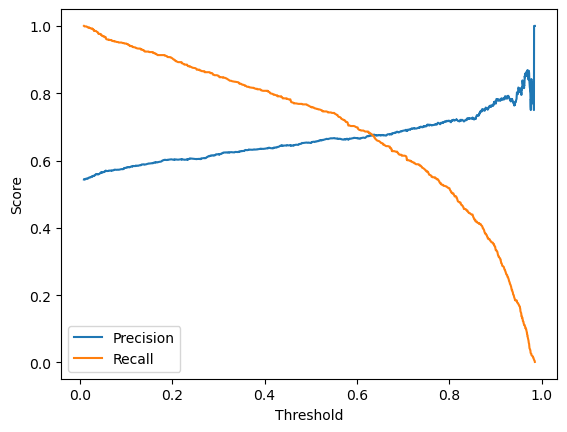

In [40]:
plt.plot(threshold, precision[:-1], label="Precision")
plt.plot(threshold, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()

## Evaluate

Get baseline metrics

In [41]:
win_prob = y_val.mean()

majority_class = int(win_prob >= 0.5)
y_baseline_pred = np.full_like(y_val, majority_class)
y_baseline_prob = np.full_like(y_val, win_prob, dtype=float)

baseline_acc = accuracy_score(y_val, y_baseline_pred)
baseline_log_loss = logLoss(y_val, y_baseline_prob)
baseline_brier = brier_score_loss(y_val, y_baseline_prob)

print(f"Baseline accuracy: {baseline_acc:.4f}")
print(f"Baseline Log Loss: {baseline_log_loss:.4f}")
print(f"Baseline Brier score: {baseline_brier:.4f}")

Baseline accuracy: 0.5435
Baseline Log Loss: 0.6894
Baseline Brier score: 0.2481


Compare to model metrics

In [42]:
y_pred = (y_pred_prob >= best_threshold)

acc = accuracy_score(y_val, y_pred)
log_loss = logLoss(y_val, y_pred_prob)
brier_score = brier_score_loss(y_val, y_pred_prob)
print(f"Accuracy: {acc:.4f}")
print(f"Log Loss: {log_loss:.4f}")
print(f"Brier Score: {brier_score:.4f}")

Accuracy: 0.6499
Log Loss: 0.7517
Brier Score: 0.2482


Other information

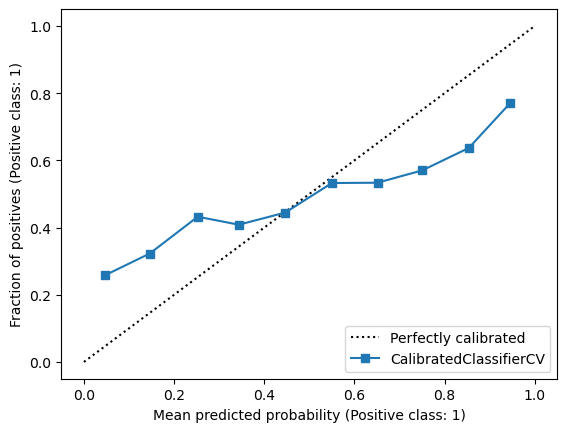

In [44]:
CalibrationDisplay.from_estimator(calibrated_model, X_val, y_val, n_bins=10) 

ROC-AUC: 0.6959928506455164


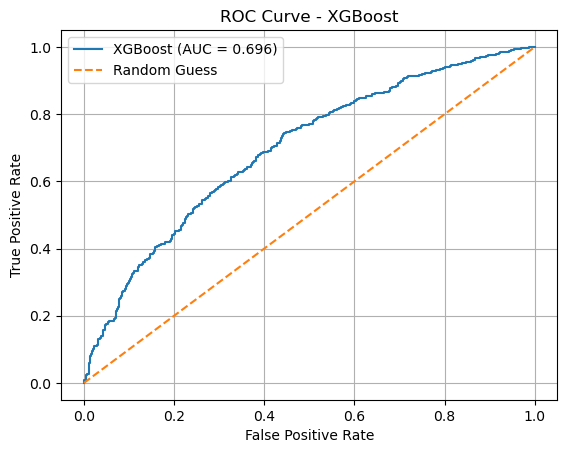

In [45]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
roc_auc = roc_auc_score(y_val, y_pred_prob)

print("ROC-AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], '--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(True)

Text(0.5, 1.0, 'Confusion Matrix Heatmap')

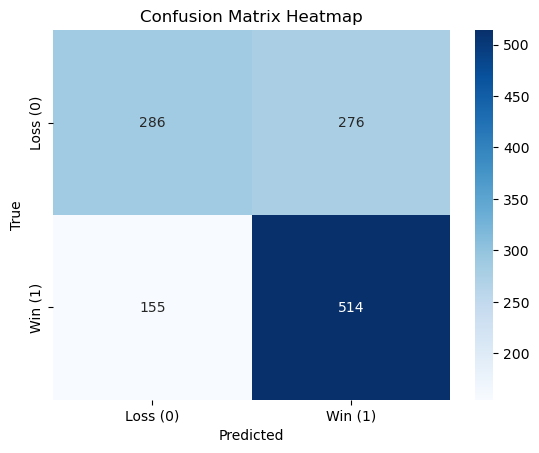

In [46]:
cm = confusion_matrix(y_val, y_pred)

labels = ["Loss (0)", "Win (1)"]

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")

## Backtest

No odds data :(